In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import pyarrow
from matplotlib.pylab import matrix
import networkx as nx

In [ ]:
# Read in ranom sample csv file using direct path 

file_path = '../data/sample/randomly_sampled_1000_drugs.parquet'
df = pd.read_parquet(file_path)
print(df.head())

In [8]:
# Slim the df to just DrugBank Id and ATC Code
slim_df = df[['drug/drugbank-id', 'drug/atc_codes']]
print(slim_df.head())

  drug/drugbank-id                                     drug/atc_codes
0          DB02351  [{'code': 'B01AE06', 'levels': [{'code': 'B01A...
1        APRD00718  [{'code': 'N05AF03', 'levels': [{'code': 'N05A...
2        BIOD00036  [{'code': 'R02AB30', 'levels': [{'code': 'R02A...
3          DB12161  [{'code': 'N07XX16', 'levels': [{'code': 'N07X...
4          DB11575  [{'code': 'J05AP11', 'levels': [{'code': 'J05A...


In [99]:
class ATCSimilarityCalculator:

    # Initiate global class objects
    def __init__(self, slim_df, matrix_length = 10, matrix_width = 10 ):
        self.slim_df = slim_df
        self.sim_matrix = np.zeros((matrix_length, matrix_width))
        
    def build_drug_atc_matrix(self,n=10):

        all_codes = set() # Initialize an empty set to store unique ATC codes

        for atc_list in self.slim_df['drug/atc_codes'].iloc[:n]: # Loop through the first n rows of the 'drug/atc_codes' column in the slim_df DataFrame
            if isinstance(atc_list, np.ndarray): # Check if the current entry is a numpy array (i.e., it contains ATC codes)
                for atc_dict in atc_list: # Loop through each ATC code in the array
                    if isinstance(atc_dict, dict) and 'code' in atc_dict: # Check if the ATC code is a dictionary and contains the 'code' key
                        all_codes.add(atc_dict['code']) # Add the ATC code to the set of unique codes
   
        all_codes = sorted(all_codes) # Sort the unique ATC codes in alphabetical order


    # Build Matrix: rows are drugs, columns are ATC codes, values are 1 if drug has ATC code and 0 otherwise (should have been filtered out before but just in case)
    


       
        M = np.zeros((n, len(all_codes))) # Initialize a matrix of zeros with dimensions n x number of unique ATC codes
        for i in range(n): # Loop through the first n rows of the slim_df DataFrame
            atc_list = self.slim_df['drug/atc_codes'].iloc[i] # Get the list of ATC codes for the current drug
            if isinstance(atc_list, np.ndarray): # Check if the current entry is a numpy array (i.e., it contains ATC codes)
                for atc_dict in atc_list: # Loop through each ATC code in the array
                    if isinstance(atc_dict, dict) and 'code' in atc_dict: # Check if the ATC code is a dictionary and contains the 'code' key
                        atc_code = atc_dict['code'] # Get the ATC code from the dictionary
                        if atc_code in all_codes: # Check if the ATC code is in the set of unique codes
                            j = all_codes.index(atc_code) # Get the index of the ATC code in the sorted list of unique codes
                            M[i][j] = 1 # Set the value in the matrix to 1 to indicate that the drug has this ATC code
    
        self.drug_atc_matrix = M # Store the drug-ATC matrix as a class attribute (object variable)
        self.atc_codes = all_codes # Store the list of unique ATC codes as a class attribute (object variable)

    def kernel_semantic(self, atc_code_1, atc_code_2):
        """Calculate the kernel semantic similarity between two ATC codes based on their hierarchical structure in the ATC classification system."""
        # This is a placeholder function and should be implemented based on the specific kernel method chosen (e.g., diffusion kernel, random walk kernel, etc.)
        pass


    def kernel_gip(self, vector_a, vector_b, gamma):
        """GIP: Gaussian Interaction Profile Kernel
        K_GIP(aj, ak) = exp(-gamma * ||Vr(aj) - Vr(ak)||^2)
        """

        diff = vector_a - vector_b
        euclidean_distance_sq = np.sum(diff ** 2) # Calculate the squared Euclidean distance between the two vectors
        
        return np.exp(-gamma * euclidean_distance_sq)
    
    def kernel_corr(self, vector_a, vector_b):
        """
        K_CORR(aj, ak) = Cov(Vr(aj) . Vr(ak)) / squrt[Var(||Vr(aj)|| * ||Vr(ak)||)]
        """
        numberator = np.cov(vector_a, vector_b) # Calculate the covariance between the two vectors
        variance_a = np.var(vector_a) # Calculate the variance of the first vector
        variance_b = np.var(vector_b) # Calculate the variance of the second vector

        denominator = np.sqrt(variance_a * variance_b) # Calculate the denominator as the square root of the product of the variances

        result = numberator / denominator if denominator != 0 else 0.0 # Calculate the correlation kernel value, handling the case where the denominator is zero to avoid division by zero error
        return result

    def kernel_cos(self, vector_a, vector_b):
        """K_COS(aj, ak) = (Vr(aj) . Vr(ak))^T / (||Vr(aj)|| * ||Vr(ak)||)"""
    
        dot_product = np.dot(vector_a, vector_b) # Calculate the dot product of the two vectors
        norm_a = np.linalg.norm(vector_a) # Calculate the L2 norm (magnitude) of the first vector
        norm_b = np.linalg.norm(vector_b) # Calculate the L2 norm (magnitude) of the second vector

        if norm_a == 0 or norm_b == 0: # Check if either of the norms is zero to avoid division by zero error
            return 0.0

        denominator = norm_a * norm_b # Calculate the denominator as the product of the norms

        result = dot_product / denominator if denominator != 0 else 0.0 # Calculate the cosine similarity kernel value, handling the case where the denominator is zero to avoid division by zero error
        return result
    


    def kernel_mi(self, vector_a, vector_b):
        """K_MI(aj, ak) = I(Vr(aj) . Vr(ak)) / sqrt(H(Vr(aj)) * H(Vr(ak)))"""
        # This is a placeholder function and should be implemented based on the specific mutual information calculation method chosen
        pass

    def kernel_jaccard(self, vector_a, vector_b):
        """Jaccard: Jaccard Similarity on Feature Vectors
        K_Jaccard(aj, ak) = |intersection| / |union|
        """
        # Binarize vectors (presence/absence)
        bin_a = (vector_a > 0).astype(int)
        bin_b = (vector_b > 0).astype(int)
        
        intersection = np.sum(bin_a & bin_b)
        union = np.sum(bin_a | bin_b)
        
        if union == 0:
            return 0.0
        
        return intersection / union 


    def simple_jaccard_atc_compare(self, drug1_atc, drug2_atc): 
        
        if drug1_atc == drug2_atc:
            return 1.0
        
          # Extract all prefixes at ATC hierarchy levels (e.g., 'B01AE06' -> ['B', 'B01', 'B01A', 'B01AE', 'B01AE06'])
        prefixes1 = {drug1_atc[:i] for i in [1, 3, 4, 5, 7]} # Slice atc code at indexes corresponding to the levels of the ATC hierarchy (1, 3, 4, 5, 7) and create a set of prefixes for the first ATC code
        prefixes2 = {drug2_atc[:i] for i in [1, 3, 4, 5, 7]}
        
        intersection = len(prefixes1 & prefixes2)
        union = len(prefixes1 | prefixes2)

        """Simple method to compare two ATC codes via matching levels via the jaccard index and return a similarity score."""

        # Compare the two ATC codes and return a similarity score
        # For simplicity, we will use Jaccard similarity
        set1 = set(prefixes1) # Convert the prefixes of the first ATC code into a set
        set2 = set(prefixes2) # Convert the prefixes of the second ATC code into a set

        intersection = len(set1.intersection(set2)) # `Calculate the intersection of the two sets using the set intersection method
        union = len(set1.union(set2)) # Calculate the union of the two sets using the set union method

        if union == 0: # Check if the union is zero to avoid division by zero error
            return 0.0

        similarity_score = (2*intersection + 1) / (union+1) # Calculate the Jaccard similarity score as the ratio of the intersection to the union (BASED ON HYPERPARAMTERS IN PAPER)
        return similarity_score

    def extract_atc_codes(self, n = 10):

        print('Beginning Association computation...')


        for i in range(n):
            current_drug_atc_dict_list = self.slim_df['drug/atc_codes'].iloc[i]

            if not isinstance(current_drug_atc_dict_list, (np.ndarray)) or len(current_drug_atc_dict_list) == 0:
                continue

            for j in range(n):
                compare_drug_atc_dict_list = self.slim_df['drug/atc_codes'].iloc[j]

                if not isinstance(compare_drug_atc_dict_list, (np.ndarray)) or len(compare_drug_atc_dict_list) == 0:
                    self.sim_matrix[i][j] = 0.0
                    continue

                similarity_score = self.average_pairwise_sim(current_drug_atc_dict_list, compare_drug_atc_dict_list)
                
                self.sim_matrix[i][j] = similarity_score

        return self.sim_matrix


    def average_pairwise_sim(self, drug1_atc_dict_list, drug2_atc_dict_list, kernel_method = 'simple_jaccard'):
        """If a drug has multiple ATC codes, we can calculate the average pairwisie
        similarity score across all ATC codes for a drug pair."""

        scores = [] # Initialize an empty list to store the similarity scores for each pair of ATC codes

        for atc_dict in drug1_atc_dict_list:
            if not isinstance(atc_dict, dict): # Check if the ATC code is not a dictionary (i.e., it is a string or other type)
                continue # Skip this ATC code and move to the next one in the list
            atc_1_code = atc_dict['code']  # Loop through each ATC code for the current drug
            
            for atc2 in drug2_atc_dict_list: # Loop through each ATC code for the current drug again to compare against the first ATC code
                if not isinstance(atc2, dict): # Check if the ATC code is not a dictionary (i.e., it is a string or other type)
                    continue # Skip this ATC code and move to the next one in the list

                atc_2_code = atc2['code']  # Get the ATC code for the second drug
                
                try:
                    idx1 = self.atc_codes.index(atc_1_code)
                    idx2 = self.atc_codes.index(atc_2_code)
                    
                    vector_aj = self.drug_atc_matrix[:, idx1]
                    vector_ak = self.drug_atc_matrix[:, idx2]
                    
                    if kernel_method == 'gip':
                        score = self.kernel_gip(vector_aj, vector_ak)
                    elif kernel_method == 'corr':
                        score = self.kernel_corr(vector_aj, vector_ak)
                    elif kernel_method == 'cos':
                        score = self.kernel_cos(vector_aj, vector_ak)
                    elif kernel_method == 'mi':
                        score = self.kernel_mi(vector_aj, vector_ak)
                    elif kernel_method == 'jaccard':
                        score = self.kernel_jaccard(vector_aj, vector_ak)
                    else:
                        score = self.kernel_semantic(atc_1_code, atc_2_code)
                    
                    scores.append(score)
                except Exception as e:
                    print(f"Error comparing ATC codes {atc_1_code} and {atc_2_code}: {e}")
                    continue

        if len(scores) == 0: # Check if there are no scores to avoid division by zero error
            return 0.0
        
        average_score = sum(scores) / len(scores) # Calculate the average similarity score by summing the scores and dividing by the number of scores
        return average_score # Return the average similarity score for the pair of drugs





In [100]:
# Test 

# Semantic kernel (simplest)
sim_calc = ATCSimilarityCalculator(slim_df)
matrix_semantic = sim_calc.extract_atc_codes(n=10)

# Feature-based kernels (requires drug-ATC association matrix)
sim_calc2 = ATCSimilarityCalculator(slim_df)
matrix_gip = sim_calc2.extract_atc_codes_with_kernels(n=10, kernel_type='gip')
matrix_cos = sim_calc2.extract_atc_codes_with_kernels(n=10, kernel_type='cos')
matrix_corr = sim_calc2.extract_atc_codes_with_kernels(n=10, kernel_type='corr')
matrix_mi = sim_calc2.extract_atc_codes_with_kernels(n=10, kernel_type='mi')
matrix_jaccard = sim_calc2.extract_atc_codes_with_kernels(n=10, kernel_type='jaccard')

Beginning Association computation...
Error comparing ATC codes B01AE06 and B01AE06: 'ATCSimilarityCalculator' object has no attribute 'atc_codes'
Error comparing ATC codes B01AE06 and N05AF03: 'ATCSimilarityCalculator' object has no attribute 'atc_codes'
Error comparing ATC codes B01AE06 and R02AB30: 'ATCSimilarityCalculator' object has no attribute 'atc_codes'
Error comparing ATC codes B01AE06 and N07XX16: 'ATCSimilarityCalculator' object has no attribute 'atc_codes'
Error comparing ATC codes B01AE06 and J05AP11: 'ATCSimilarityCalculator' object has no attribute 'atc_codes'
Error comparing ATC codes B01AE06 and J05AP54: 'ATCSimilarityCalculator' object has no attribute 'atc_codes'
Error comparing ATC codes B01AE06 and D10AF01: 'ATCSimilarityCalculator' object has no attribute 'atc_codes'
Error comparing ATC codes B01AE06 and J01FF01: 'ATCSimilarityCalculator' object has no attribute 'atc_codes'
Error comparing ATC codes B01AE06 and D10AF51: 'ATCSimilarityCalculator' object has no attr

AttributeError: 'ATCSimilarityCalculator' object has no attribute 'extract_atc_codes_with_kernels'

In [101]:
def fuse_kernels(self, drug1_atc_dict_list, drug2_atc_dict_list, drug1_idx, drug2_idx, weights=None):
    """Fuse multiple kernels for final similarity score.
    
    K* = β1*K_semantic + β2*K_gip + β3*K_corr + β4*K_cos + β5*K_mi + β6*K_jaccard
    """
    if weights is None:
        # Equal weights if not specified --. Found based on a an optimization problem in the paper to find the best performing weights for each kernel --> Try later

        weights = {'semantic': 1/6, 'gip': 1/6, 'corr': 1/6, 'cos': 1/6, 'mi': 1/6, 'jaccard': 1/6}
    
    kernel_scores = {}
    
    # Calculate each kernel
    kernel_scores['semantic'] = self.average_pairwise_sim(drug1_atc_dict_list, drug2_atc_dict_list)
    kernel_scores['gip'] = self.average_pairwise_sim_kernel(drug1_atc_dict_list, drug2_atc_dict_list, 'gip', drug1_idx, drug2_idx)
    kernel_scores['corr'] = self.average_pairwise_sim_kernel(drug1_atc_dict_list, drug2_atc_dict_list, 'corr', drug1_idx, drug2_idx)
    kernel_scores['cos'] = self.average_pairwise_sim_kernel(drug1_atc_dict_list, drug2_atc_dict_list, 'cos', drug1_idx, drug2_idx)
    kernel_scores['mi'] = self.average_pairwise_sim_kernel(drug1_atc_dict_list, drug2_atc_dict_list, 'mi', drug1_idx, drug2_idx)
    kernel_scores['jaccard'] = self.average_pairwise_sim_kernel(drug1_atc_dict_list, drug2_atc_dict_list, 'jaccard', drug1_idx, drug2_idx)
    
    # Fuse with weights
    fused_score = sum(weights[k] * kernel_scores[k] for k in kernel_scores)
    
    return fused_score

def extract_atc_codes_fused(self, n=10, weights=None):
    """Build similarity matrix using fused kernels."""
    print('Beginning Association computation with kernel fusion...')
    
    self.build_drug_atc_matrix(n)
    
    if weights is None:
        weights = {'semantic': 1/6, 'gip': 1/6, 'corr': 1/6, 'cos': 1/6, 'mi': 1/6, 'jaccard': 1/6}
    
    for i in range(n):
        current_drug_atc = self.slim_df['drug/atc_codes'].iloc[i]

        if not isinstance(current_drug_atc, np.ndarray) or len(current_drug_atc) == 0:
            continue

        for j in range(n):
            compare_drug_atc = self.slim_df['drug/atc_codes'].iloc[j]

            if not isinstance(compare_drug_atc, np.ndarray) or len(compare_drug_atc) == 0:
                self.sim_matrix[i][j] = 0.0
                continue

            similarity_score = self.fuse_kernels(current_drug_atc, compare_drug_atc, i, j, weights)
            self.sim_matrix[i][j] = similarity_score

    return self.sim_matrix

In [ ]:
def find_optimal_weights(self, validation_data):
    """Find optimal weights for kernel fusion using a validation set."""
    # This is a placeholder function and should be implemented based on the specific optimization method 
    pass

In [97]:
# Below is example code

sim_calc = ATCSimilarityCalculator(slim_df)
sim_matrix = sim_calc.extract_atc_codes()

with np.printoptions(precision=2):
    print(sim_matrix)
    print(np.diag(sim_matrix)) # Not all ones because some drugs have multiple ATC codes that are not the same, 
                            # So instead of being 1s across the diagonal, we get similarity scores that are less than 1 for some drugs.

    



Beginning Association computation...
[[1.   0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.09]
 [0.09 1.   0.09 0.3  0.09 0.09 0.09 0.3  0.09 0.09]
 [0.09 0.09 1.   0.09 0.09 0.09 0.09 0.09 0.09 0.09]
 [0.09 0.3  0.09 1.   0.09 0.09 0.09 0.3  0.09 0.09]
 [0.09 0.09 0.09 0.09 1.14 0.14 0.09 0.09 0.09 0.09]
 [0.09 0.09 0.09 0.09 0.14 0.47 0.09 0.09 0.19 0.09]
 [0.09 0.09 0.09 0.09 0.09 0.09 1.   0.09 0.09 0.3 ]
 [0.09 0.3  0.09 0.3  0.09 0.09 0.09 1.   0.09 0.09]
 [0.09 0.09 0.09 0.09 0.09 0.19 0.09 0.09 0.55 0.09]
 [0.09 0.09 0.09 0.09 0.09 0.09 0.3  0.09 0.09 1.  ]]
[1.   1.   1.   1.   1.14 0.47 1.   1.   0.55 1.  ]


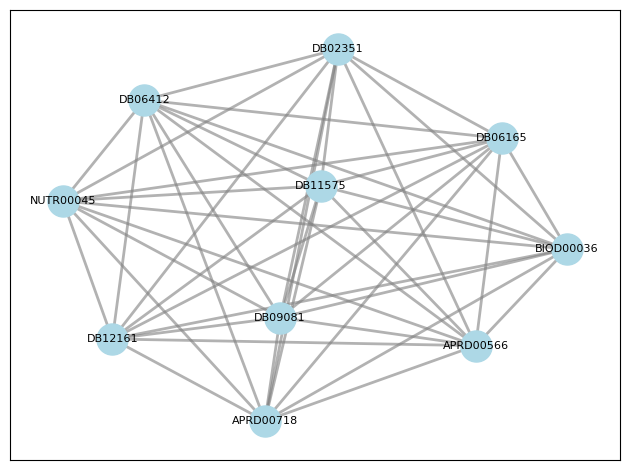

In [ ]:
G = nx.Graph()
threshold = 0 # Example threshold for similarity to create an edge in the graph
for i in range(len(sim_matrix)):
    for j in range(i+1, len(sim_matrix)): # Only upper triangle to avoid duplicate edges (Self comparisons) in an undirected graph
        if sim_matrix[i][j] > 0: # Assuming a threshold of 0 for similarity
            if sim_matrix[i][j] > threshold:
                G.add_edge(i, j, weight=sim_matrix[i][j])
for i in range(len(sim_matrix)):
    G.add_node(i, label=slim_df['drug/drugbank-id'].iloc[i]) # Add node labels as drugbank ids

labels = nx.get_node_attributes(G, 'label')
# Draw with visible edges
nx.draw_networkx_nodes(G, pos := nx.spring_layout(G), label=labels, node_color='lightblue', node_size=500)
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', alpha=0.6)
nx.draw_networkx_labels(G, pos, labels, font_size=8)
plt.tight_layout()
plt.show()